In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [6]:
housing = fetch_california_housing()

X = housing.data
y = housing.target

print("Dataset Shape:", X.shape)

Dataset Shape: (20640, 8)


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

y_pred = lr_model.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, y_pred)
lr_mse = mean_squared_error(y_test, y_pred)
lr_rmse = np.sqrt(lr_mse)
lr_r2 = r2_score(y_test, y_pred)

print("Linear Regression")
print("MAE :", lr_mae)
print("MSE :", lr_mse)
print("RMSE:", lr_rmse)
print("R2 :", lr_r2)

Linear Regression
MAE : 0.5332001304956566
MSE : 0.5558915986952442
RMSE: 0.7455813830127763
R2 : 0.575787706032451


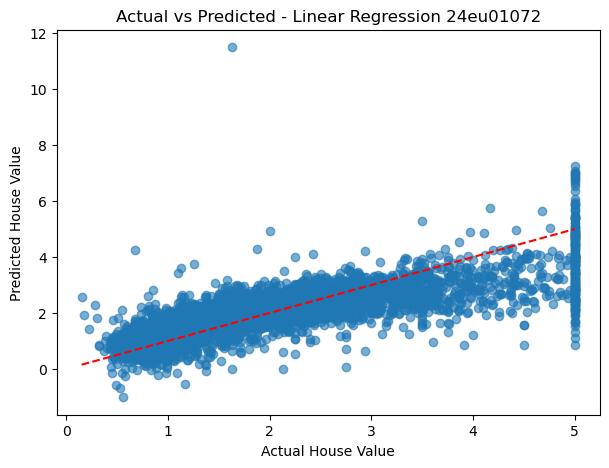

In [18]:
plt.figure(figsize=(7,5))

plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted - Linear Regression 24eu01072")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.show()

In [20]:
svr_model = SVR(kernel='rbf')

svr_model.fit(X_train_scaled, y_train)

svr_predictions = svr_model.predict(X_test_scaled)

svr_mae = mean_absolute_error(y_test, svr_predictions)
svr_mse = mean_squared_error(y_test, svr_predictions)
svr_rmse = np.sqrt(svr_mse)
svr_r2 = r2_score(y_test, svr_predictions)

print("Support Vector Regression")
print("MAE :", svr_mae)
print("MSE :", svr_mse)
print("RMSE:", svr_rmse)
print("R2 :", svr_r2)

Support Vector Regression
MAE : 0.3985982830145761
MSE : 0.35700264267544685
RMSE: 0.59749698131074
R2 : 0.727563952473304


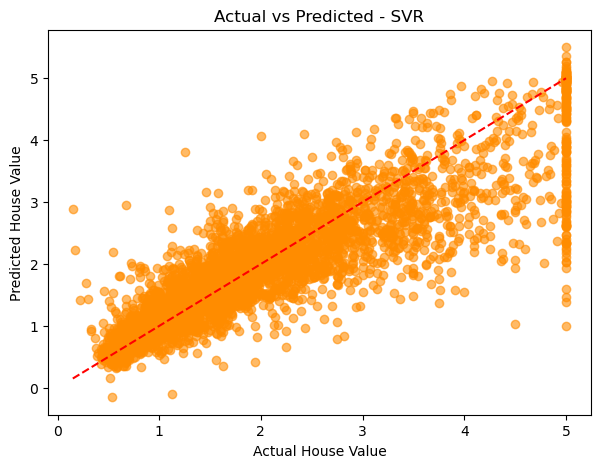

In [21]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    svr_predictions,
    color='darkorange',
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted - SVR")
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.show()

In [24]:
dt_model = DecisionTreeRegressor(random_state=42)

dt_model.fit(X_train, y_train)

dt_predictions = dt_model.predict(X_test)

dt_mae = mean_absolute_error(y_test, dt_predictions)
dt_mse = mean_squared_error(y_test, dt_predictions)
dt_rmse = np.sqrt(dt_mse)
dt_r2 = r2_score(y_test, dt_predictions)

print("Decision Tree Regression")
print("MAE :", dt_mae)
print("MSE :", dt_mse)
print("RMSE:", dt_rmse)
print("R2 :", dt_r2)

Decision Tree Regression
MAE : 0.45467918846899225
MSE : 0.495235205629094
RMSE: 0.7037294974840077
R2 : 0.622075845135081


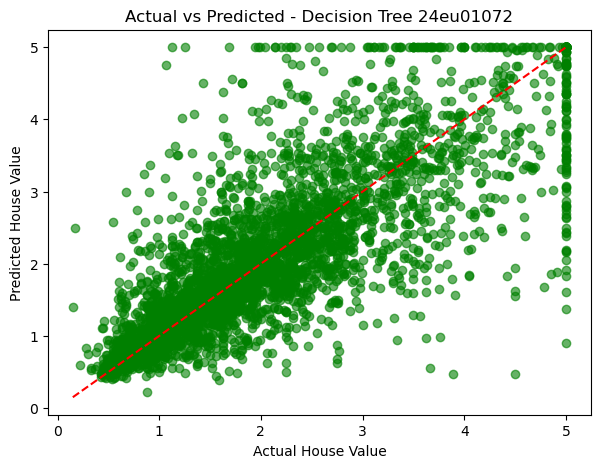

In [28]:
plt.figure(figsize=(7,5))

plt.scatter(
    y_test,
    dt_predictions,
    color='green',
    alpha=0.6
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--'
)

plt.title("Actual vs Predicted - Decision Tree 24eu01072" )
plt.xlabel("Actual House Value")
plt.ylabel("Predicted House Value")

plt.show()

In [30]:
performance = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Support Vector Regression",
        "Decision Tree Regression"
    ],

    "MAE":[
        lr_mae,
        svr_mae,
        dt_mae
    ],

    "MSE":[
        lr_mse,
        svr_mse,
        dt_mse
    ],

    "RMSE":[
        lr_rmse,
        svr_rmse,
        dt_rmse
    ],

    "R2 Score":[
        lr_r2,
        svr_r2,
        dt_r2
    ]

})

print(performance)

                       Model       MAE       MSE      RMSE  R2 Score
0          Linear Regression  0.533200  0.555892  0.745581  0.575788
1  Support Vector Regression  0.398598  0.357003  0.597497  0.727564
2   Decision Tree Regression  0.454679  0.495235  0.703729  0.622076


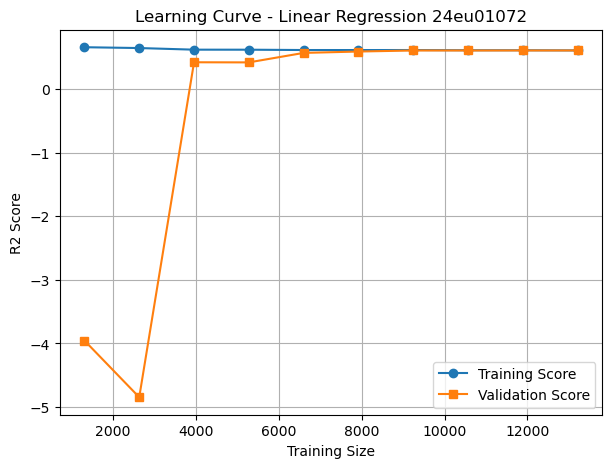

In [34]:
train_sizes, train_scores, test_scores = learning_curve(

    LinearRegression(),

    X_train_scaled,

    y_train,

    cv=5,

    scoring="r2",

    train_sizes=np.linspace(0.1,1.0,10)

)

train_mean=np.mean(train_scores,axis=1)
test_mean=np.mean(test_scores,axis=1)

plt.figure(figsize=(7,5))

plt.plot(train_sizes,train_mean,marker='o',label="Training Score")
plt.plot(train_sizes,test_mean,marker='s',label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve - Linear Regression 24eu01072")

plt.legend()

plt.grid(True)

plt.show()

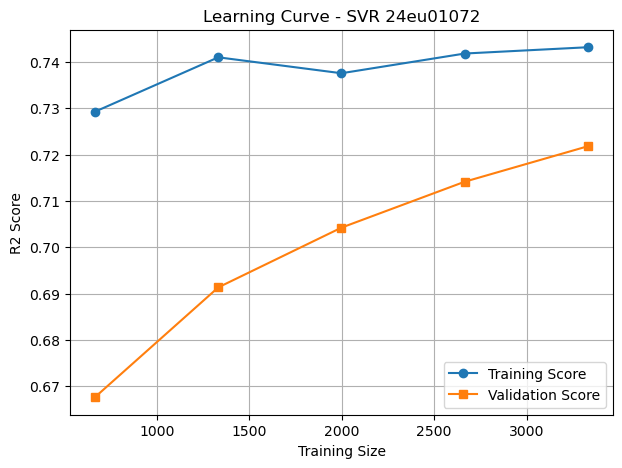

In [37]:
X_small = X_train_scaled[:5000]
y_small = y_train[:5000]

train_sizes, train_scores, test_scores = learning_curve(

    SVR(),

    X_small,

    y_small,

    cv=3,

    scoring="r2",

    train_sizes=np.linspace(0.2,1.0,5),

    n_jobs=-1

)

train_mean=np.mean(train_scores,axis=1)
test_mean=np.mean(test_scores,axis=1)

plt.figure(figsize=(7,5))

plt.plot(train_sizes,train_mean,marker='o',label="Training Score")
plt.plot(train_sizes,test_mean,marker='s',label="Validation Score")

plt.xlabel("Training Size")
plt.ylabel("R2 Score")
plt.title("Learning Curve - SVR 24eu01072")

plt.legend()

plt.grid(True)

plt.show()